# Options Greeks — Trading Cheat Sheet

A quick-reference guide to the Greeks: what they measure, their typical ranges, and how traders use them.

---

## Setup

We'll use `numpy` for math and `matplotlib` for quick visualizations. Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Black-Scholes helpers
def d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_call(S, K, T, r, sigma):
    _d1, _d2 = d1(S,K,T,r,sigma), d2(S,K,T,r,sigma)
    return S * norm.cdf(_d1) - K * np.exp(-r * T) * norm.cdf(_d2)

def bs_put(S, K, T, r, sigma):
    _d1, _d2 = d1(S,K,T,r,sigma), d2(S,K,T,r,sigma)
    return K * np.exp(-r * T) * norm.cdf(-_d2) - S * norm.cdf(-_d1)

print("Ready.")

Ready.


---
## 1. Delta (Δ)

**What it measures:** Rate of change of option price with respect to a $1 move in the underlying.

| | Call | Put |
|---|---|---|
| Range | 0 to +1 | -1 to 0 |
| ATM approximation | ~+0.50 | ~-0.50 |
| Deep ITM | approaches +1 | approaches -1 |
| Deep OTM | approaches 0 | approaches 0 |

**Formula:**
$$\Delta_{call} = N(d_1) \qquad \Delta_{put} = N(d_1) - 1$$

**Trading uses:**
- **Hedge ratio:** buy/sell Δ shares of stock to delta-hedge one option contract
- **Probability proxy:** an option with Δ = 0.30 is roughly 30% likely to expire ITM
- **Position sizing:** a portfolio's net delta tells you your effective equity exposure
- **Delta-neutral strategies:** iron condors, straddles, and strangles are set up at or near zero net delta

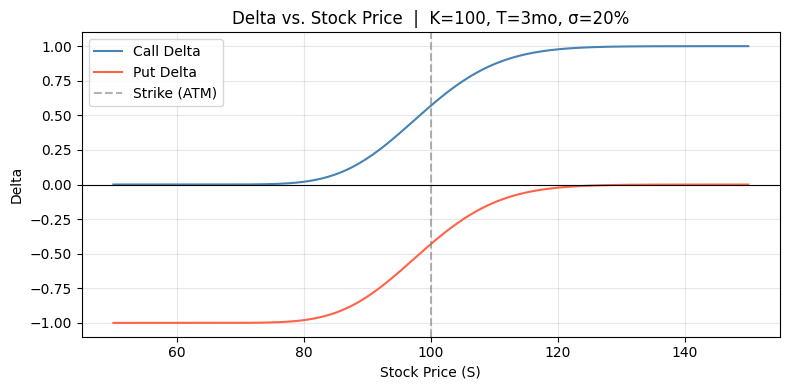

In [2]:
S_range = np.linspace(50, 150, 300)
K, T, r, sigma = 100, 0.25, 0.05, 0.20

call_delta = norm.cdf(d1(S_range, K, T, r, sigma))
put_delta  = call_delta - 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S_range, call_delta, label='Call Delta', color='steelblue')
ax.plot(S_range, put_delta,  label='Put Delta',  color='tomato')
ax.axvline(K, color='gray', linestyle='--', alpha=0.6, label='Strike (ATM)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Stock Price (S)')
ax.set_ylabel('Delta')
ax.set_title('Delta vs. Stock Price  |  K=100, T=3mo, σ=20%')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Gamma (Γ)

**What it measures:** Rate of change of **Delta** with respect to a $1 move in the underlying (second-order price sensitivity).

| | Calls & Puts |
|---|---|
| Always | positive for long options, negative for short options |
| Highest | at-the-money, near expiration |
| Lowest | deep ITM or OTM |

**Formula:**
$$\Gamma = \frac{N'(d_1)}{S \cdot \sigma \cdot \sqrt{T}}$$

**Trading uses:**
- **Gamma scalping:** long-gamma traders delta-hedge frequently to capture realized vol vs. implied vol (P&L ≈ ½ · Γ · (realized σ)²)
- **Risk gauge:** high gamma means delta changes fast — a gap move can blow through your hedge
- **Short gamma risk:** sellers of premium (iron condors, covered calls) are short gamma and hurt by large moves
- **Gamma squeeze (market structure):** when dealers are short gamma, they must buy as price rises and sell as it falls, amplifying moves (e.g., meme-stock squeezes)

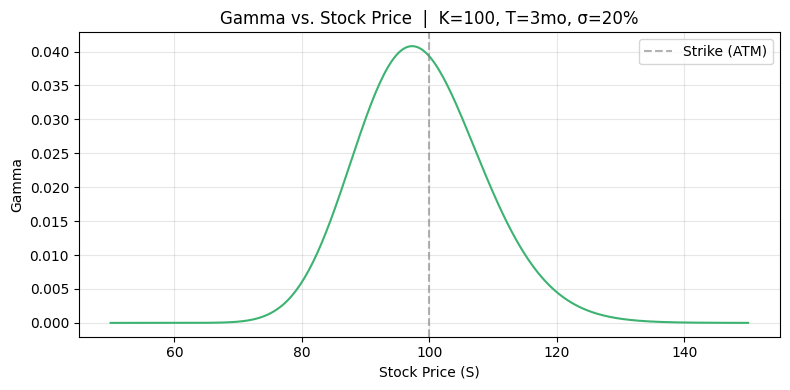

In [3]:
gamma = norm.pdf(d1(S_range, K, T, r, sigma)) / (S_range * sigma * np.sqrt(T))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S_range, gamma, color='mediumseagreen')
ax.axvline(K, color='gray', linestyle='--', alpha=0.6, label='Strike (ATM)')
ax.set_xlabel('Stock Price (S)')
ax.set_ylabel('Gamma')
ax.set_title('Gamma vs. Stock Price  |  K=100, T=3mo, σ=20%')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Theta (Θ)

**What it measures:** Rate of change of option price with respect to the **passage of time** (time decay). Usually quoted as the dollar change per calendar day.

| | Calls & Puts |
|---|---|
| Sign (long options) | negative (you lose value each day) |
| Sign (short options) | positive (you collect decay) |
| Highest decay | ATM, near expiration |

**Formula (call, annualized → divide by 365 for daily):**
$$\Theta_{call} = -\frac{S \cdot N'(d_1) \cdot \sigma}{2\sqrt{T}} - r K e^{-rT} N(d_2)$$

**Trading uses:**
- **Premium selling:** short straddles, iron condors, covered calls collect theta — the core trade of volatility sellers
- **Theta/Vega trade-off:** you're always long one and short the other; selling theta means you're short vol (vega)
- **DTE management:** theta accelerates in the final 30-45 days — sellers often target this window ("theta burn zone")
- **Rule of thumb:** ATM option loses ~1/3 of its value in the final third of its life, not linearly

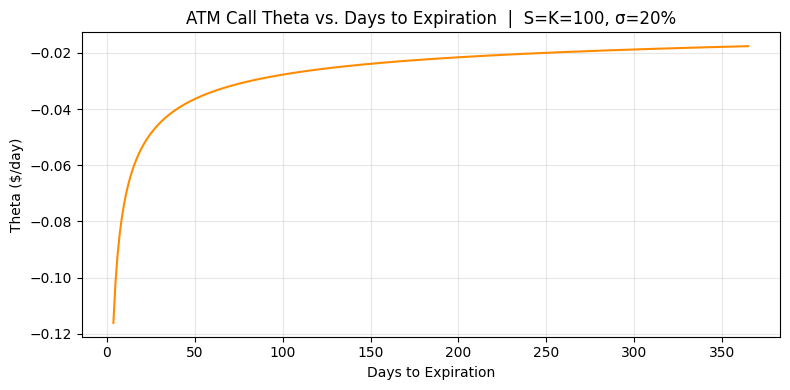

In [4]:
T_range = np.linspace(0.01, 1.0, 300)  # 3.6 days to 1 year
S_atm = 100

def theta_call(S, K, T, r, sigma):
    _d1 = d1(S, K, T, r, sigma)
    _d2 = d2(S, K, T, r, sigma)
    return (-S * norm.pdf(_d1) * sigma / (2 * np.sqrt(T))
            - r * K * np.exp(-r * T) * norm.cdf(_d2)) / 365  # daily

theta_vals = theta_call(S_atm, K, T_range, r, sigma)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_range * 365, theta_vals, color='darkorange')
ax.set_xlabel('Days to Expiration')
ax.set_ylabel('Theta ($/day)')
ax.set_title('ATM Call Theta vs. Days to Expiration  |  S=K=100, σ=20%')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Vega (ν)

**What it measures:** Rate of change of option price with respect to a **1% change in implied volatility (IV)**.

> Note: Vega is not actually a Greek letter. It's sometimes written as κ (kappa) or λ (lambda) in academic texts.

| | Calls & Puts |
|---|---|
| Sign (long options) | positive (rising IV helps you) |
| Sign (short options) | negative (rising IV hurts you) |
| Highest | ATM, long-dated options |

**Formula:**
$$\nu = S \cdot N'(d_1) \cdot \sqrt{T}$$

**Trading uses:**
- **Vol trading:** buying options before earnings/events to capture IV expansion ("long vega" into events)
- **IV crush:** post-earnings IV collapse devastates long option holders — understand your vega exposure before events
- **Calendar spreads:** long back-month / short front-month = net long vega (back month has more vega)
- **VIX as a vega proxy:** a rising VIX means your long options gain, short options lose

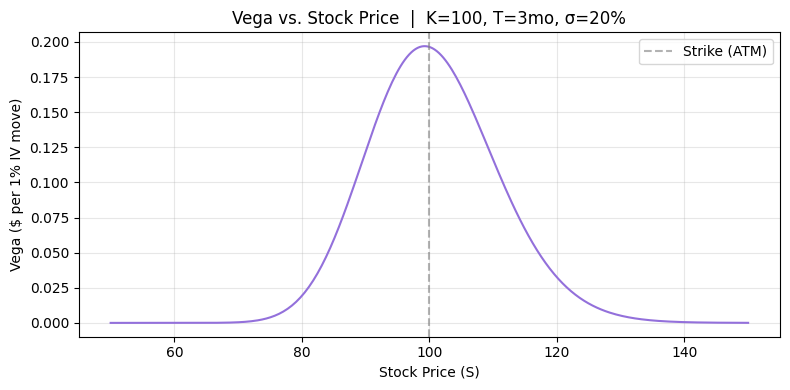

In [5]:
vega_vals = S_range * norm.pdf(d1(S_range, K, T, r, sigma)) * np.sqrt(T) / 100  # per 1% IV move

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(S_range, vega_vals, color='mediumpurple')
ax.axvline(K, color='gray', linestyle='--', alpha=0.6, label='Strike (ATM)')
ax.set_xlabel('Stock Price (S)')
ax.set_ylabel('Vega ($ per 1% IV move)')
ax.set_title('Vega vs. Stock Price  |  K=100, T=3mo, σ=20%')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Rho (ρ)

**What it measures:** Rate of change of option price with respect to a **1% change in the risk-free interest rate**.

| | Call | Put |
|---|---|---|
| Sign | positive | negative |
| Largest impact | long-dated, deep ITM options |

**Formula:**
$$\rho_{call} = K T e^{-rT} N(d_2) \qquad \rho_{put} = -K T e^{-rT} N(-d_2)$$

**Trading uses:**
- **Rate-sensitive positions:** LEAPS (long-dated options) have significant rho — important during Fed tightening/easing cycles
- **Calls benefit from rising rates** (higher cost of carry makes calls worth more vs. buying stock)
- **Puts are hurt by rising rates** (lower present value of strike makes puts less attractive)
- **Generally low-priority** for short-dated options — delta, gamma, theta, and vega dominate

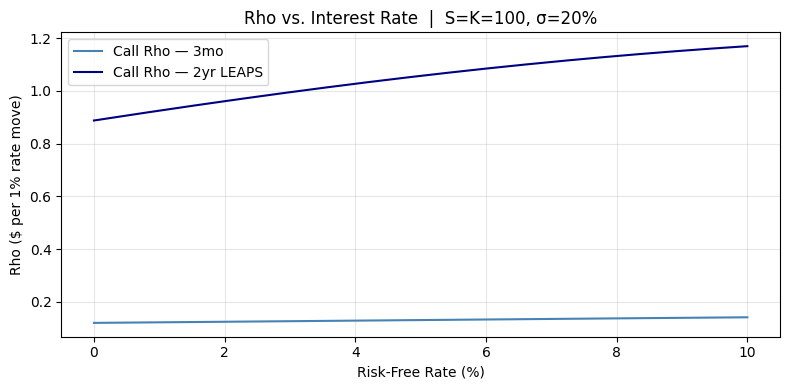

In [6]:
r_range = np.linspace(0.00, 0.10, 200)  # 0% to 10% rates
S_atm = 100

rho_call_short = K * 0.25 * np.exp(-r_range * 0.25) * norm.cdf(d2(S_atm, K, 0.25, r_range, sigma)) / 100
rho_call_long  = K * 2.0  * np.exp(-r_range * 2.0)  * norm.cdf(d2(S_atm, K, 2.0,  r_range, sigma)) / 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_range * 100, rho_call_short, label='Call Rho — 3mo',       color='steelblue')
ax.plot(r_range * 100, rho_call_long,  label='Call Rho — 2yr LEAPS', color='navy')
ax.set_xlabel('Risk-Free Rate (%)')
ax.set_ylabel('Rho ($ per 1% rate move)')
ax.set_title('Rho vs. Interest Rate  |  S=K=100, σ=20%')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Minor / Higher-Order Greeks

These become relevant for sophisticated hedging and vol-surface trading.

| Greek | Measures | Key Use |
|---|---|---|
| **Vanna** | dΔ/dσ (or dν/dS) | How delta changes as IV moves; important for hedging under vol-of-vol regimes |
| **Volga / Vomma** | d²V/dσ² (convexity w.r.t. vol) | Gains when IV moves a lot in either direction; relevant for vol-of-vol and wings |
| **Charm** | dΔ/dt (delta bleed) | How much delta drifts per day from time alone; critical for overnight hedge management |
| **Speed** | dΓ/dS | Rate of change of gamma with price; matters near expiry ATM |
| **Color** | dΓ/dt | How fast gamma changes with time; useful for managing gamma over multi-day horizons |
| **Zomma** | dΓ/dσ | How gamma responds to IV changes; used by dealers managing large gamma books |
| **DvegaDtime** | dν/dt | Rate of vega decay as expiry approaches |

---
## 7. Greeks at a Glance — Summary Table

| Greek | Sensitivity to | Call sign | Put sign | Biggest when |
|---|---|---|---|---|
| **Delta** Δ | Underlying price (1st order) | + | − | Deep ITM |
| **Gamma** Γ | Delta / price (2nd order) | + | + | ATM, near expiry |
| **Theta** Θ | Time passing | − | − | ATM, near expiry |
| **Vega** ν | Implied volatility | + | + | ATM, long-dated |
| **Rho** ρ | Interest rates | + | − | Long-dated, ITM |

---

## 8. Common Greek Relationships (Rules of Thumb)

```
Long premium  →  + Gamma, − Theta, + Vega   (you need a big move or vol spike to win)
Short premium →  − Gamma, + Theta, − Vega   (you need small moves and declining vol to win)

Gamma and Theta are always opposite in sign for the same position.
  → Gamma/Theta ratio tells you roughly how much movement you need to offset daily decay.

Vega is always the same sign as Gamma for vanilla options.

Delta is the only first-order Greek that differs in sign between calls and puts.

Put-Call Parity Greek relationships:
  Δ_call − Δ_put = 1
  Γ_call = Γ_put
  ν_call = ν_put
  Θ_call ≠ Θ_put  (put theta can be positive for deep ITM puts)
```

---
## 9. Live Greek Calculator

In [7]:
def all_greeks(S, K, T, r, sigma):
    _d1 = d1(S, K, T, r, sigma)
    _d2 = d2(S, K, T, r, sigma)
    nd1  = norm.cdf(_d1)
    nd1_ = norm.pdf(_d1)
    nd2  = norm.cdf(_d2)

    call_price = bs_call(S, K, T, r, sigma)
    put_price  = bs_put(S, K, T, r, sigma)

    delta_c =  nd1
    delta_p =  nd1 - 1
    gamma   =  nd1_ / (S * sigma * np.sqrt(T))
    vega    =  S * nd1_ * np.sqrt(T) / 100           # per 1% IV
    theta_c = (-S * nd1_ * sigma / (2 * np.sqrt(T)) - r * K * np.exp(-r*T) * nd2) / 365
    theta_p = (-S * nd1_ * sigma / (2 * np.sqrt(T)) + r * K * np.exp(-r*T) * norm.cdf(-_d2)) / 365
    rho_c   =  K * T * np.exp(-r*T) * nd2 / 100      # per 1% rate
    rho_p   = -K * T * np.exp(-r*T) * norm.cdf(-_d2) / 100

    print(f"{'':=<50}")
    print(f"  S={S}  K={K}  T={T:.2f}yr  r={r*100:.1f}%  σ={sigma*100:.0f}%")
    print(f"{'':=<50}")
    print(f"  {'Greek':<12} {'Call':>10} {'Put':>10}")
    print(f"  {'-'*32}")
    print(f"  {'Price':<12} {call_price:>10.4f} {put_price:>10.4f}")
    print(f"  {'Delta':<12} {delta_c:>10.4f} {delta_p:>10.4f}")
    print(f"  {'Gamma':<12} {gamma:>10.4f} {gamma:>10.4f}")
    print(f"  {'Theta/day':<12} {theta_c:>10.4f} {theta_p:>10.4f}")
    print(f"  {'Vega/1%':<12} {vega:>10.4f} {vega:>10.4f}")
    print(f"  {'Rho/1%':<12} {rho_c:>10.4f} {rho_p:>10.4f}")
    print(f"{'':=<50}")

# --- Edit these inputs ---
all_greeks(
    S     = 100,    # current stock price
    K     = 100,    # strike price
    T     = 0.25,   # time to expiry in years (0.25 = ~3 months)
    r     = 0.05,   # risk-free rate (5%)
    sigma = 0.20,   # implied volatility (20%)
)

  S=100  K=100  T=0.25yr  r=5.0%  σ=20%
  Greek              Call        Put
  --------------------------------
  Price            4.6150     3.3728
  Delta            0.5695    -0.4305
  Gamma            0.0393     0.0393
  Theta/day       -0.0287    -0.0152
  Vega/1%          0.1964     0.1964
  Rho/1%           0.1308    -0.1161


---
## 10. Strategy Greek Profiles

| Strategy | Net Δ | Net Γ | Net Θ | Net ν | Bet you're making |
|---|---|---|---|---|---|
| Long call | + | + | − | + | Bullish + vol rising |
| Long put | − | + | − | + | Bearish + vol rising |
| Covered call | ~0→+ | − | + | − | Mild bullish, selling vol |
| Cash-secured put | ~0→− | − | + | − | Mild bullish, selling vol |
| Long straddle | ~0 | + | − | + | Big move, any direction |
| Short straddle | ~0 | − | + | − | Small move, vol crush |
| Iron condor | ~0 | − | + | − | Range-bound, selling vol |
| Long call spread (debit) | + | ~0 | ~0 | ~0 | Directional, vol-neutral |
| Calendar spread | ~0 | − | + | + | Low near-term vol, IV expansion |
| Ratio spread (1x2 call) | + | − | + | − | Mild bull, selling vol in wings |